# Stage 3 — Classical Combination and Thresholding

Combines the continuous feature maps from Stage 2 into a single fused map, then applies classical thresholding (like Otsu's method) to produce a binary vessel mask.

In [17]:
import sys
from pathlib import Path

# Allow `from src...` imports
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np

from src.io_utils import load_fundus_image, load_fov_mask
from src.preprocessing import run_stage1
from src.feature_extraction import run_stage2
from src.postprocessing import run_stage3_classical

In [7]:
# We use a STARE image as requested. STARE lacks FOV masks.
IMAGE_PATH = str(PROJECT_ROOT / "data" / "stare" / "images" / "im0001.ppm") # Update this to an actual STARE image path
MASK_PATH = None

try:
    rgb = load_fundus_image(IMAGE_PATH)
    fov_mask = load_fov_mask(MASK_PATH)
    print("Image shape:", rgb.shape, "| Mask:", None if fov_mask is None else fov_mask.shape)
except FileNotFoundError as e:
    print(e)
    # Creating a dummy image if dataset is not downloaded yet
    print("Creating dummy image for testing.")
    rgb = np.zeros((605, 700, 3), dtype=np.uint8)
    rgb[300:310, 100:600] = [100, 50, 50] # Dummy vessel
    fov_mask = None

Image shape: (605, 700, 3) | Mask: None


In [8]:
# Run Stages 1 & 2
print("Running Stage 1...")
stage1_out = run_stage1(rgb, fov_mask)

print("Running Stage 2...")
stage2_maps = run_stage2(stage1_out)
print("Stage 2 maps:", list(stage2_maps.keys()))

Running Stage 1...
Running Stage 2...
Stage 2 maps: ['frangi', 'matched_gaussian', 'matched_cauchy', 'gabor']


In [9]:
# Run Stage 3
print("Running Stage 3...")
fused_map, binary_mask = run_stage3_classical(
    feature_dict=stage2_maps,
    fov_mask=fov_mask,
    fusion_method="mean",
    threshold_method="otsu"
)

print("Fused map shape:", fused_map.shape, "min:", fused_map.min(), "max:", fused_map.max())
print("Binary mask shape:", binary_mask.shape, "unique values:", np.unique(binary_mask))

Running Stage 3...
Fused map shape: (605, 700) min: 0.0 max: 1.0
Binary mask shape: (605, 700) unique values: [  0 255]


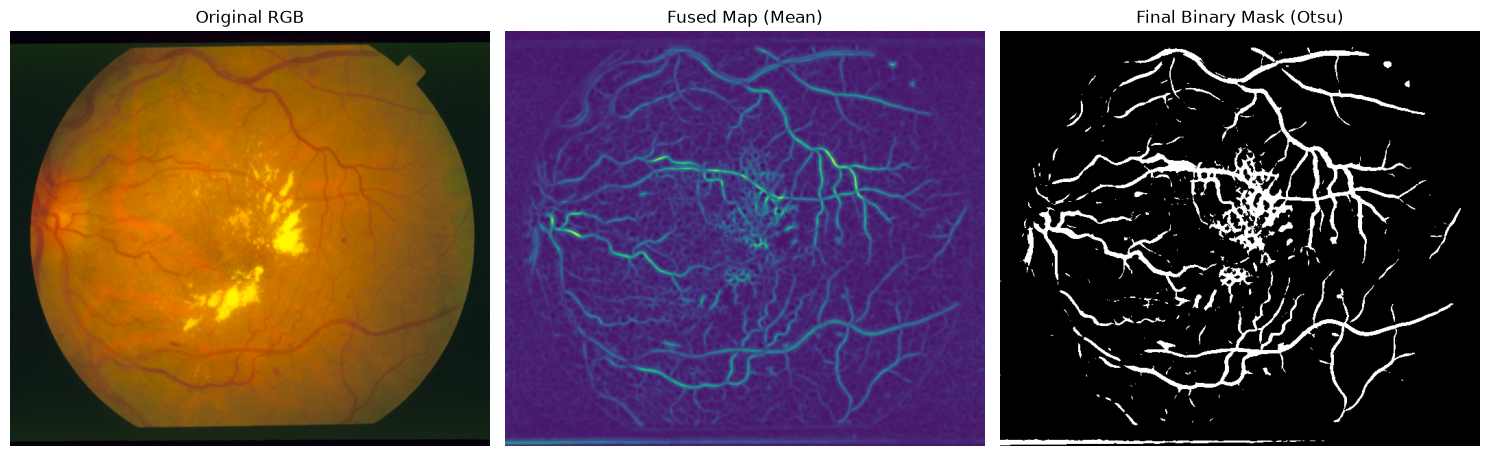

In [10]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(rgb)
axes[0].set_title("Original RGB")
axes[0].axis("off")

axes[1].imshow(fused_map, cmap="viridis")
axes[1].set_title("Fused Map (Mean)")
axes[1].axis("off")

axes[2].imshow(binary_mask, cmap="gray")
axes[2].set_title("Final Binary Mask (Otsu)")
axes[2].axis("off")

plt.tight_layout()
plt.show()